# Sprint 3 - US28 to US31

Regression Analysis for Transparency Assessment

---

## US28 — Correlação entre Rendimento Total e Tipos de Ativos por Cargo

**Descrição:**
Como membro do Comité de Ética, quero perceber se o rendimento total declarado pelos agentes políticos está alinhado com os seus ativos totais declarados. Quero analisar se existe uma mudança significativa entre a primeira e última declaração dos agentes políticos. Para um dado cargo (role) fornecido como input, quero saber com que tipo de ativos (imóveis, veículos ou ações) o rendimento total declarado (salário bruto + rendimentos laterais) apresenta a correlação mais forte. Quero comparar os resultados usando a primeira e a última declaração. *(Aplica o coeficiente de correlação de Pearson.)*

---

## Conceitos Teóricos Aplicados

### Rendimento Total
O rendimento total de cada agente político é calculado como:

$$\text{total\_income} = \text{gross\_salary} + \text{side\_income\_consulting} + \text{side\_income\_board\_memberships}$$

### Ativos Totais
Os ativos declarados dividem-se em três categorias:
- $\text{assets\_in\_real\_estate}$ — imóveis;
- $\text{assets\_in\_vehicles}$ — veículos;
- $\text{assets\_in\_stocks}$ — ações.

### Coeficiente de Correlação Amostral de Pearson
O coeficiente de correlação amostral de Pearson, $r$, é uma medida da **direção** e **grau** com que duas variáveis se associam linearmente:

$$r = \frac{S_{xy}}{\sqrt{S_{xx} \times S_{yy}}}, \qquad -1 \leq r \leq 1$$

onde:
$$S_{xx} = \sum_{i=1}^{n}(x_i - \bar{x})^2, \quad S_{yy} = \sum_{i=1}^{n}(y_i - \bar{y})^2, \quad S_{xy} = \sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

### Coeficiente de Determinação
O coeficiente de determinação $r^2$ ($0 \leq r^2 \leq 1$) representa a proporção da variabilidade total de $y$ explicada pelo modelo linear.

### Interpretação do Coeficiente de Pearson

| Coeficiente de correlação | Correlação |
|---|---|
| $r = 1$ | perfeita positiva |
| $0.8 \leq r < 1$ | forte positiva |
| $0.5 \leq r < 0.8$ | moderada positiva |
| $0.1 \leq r < 0.5$ | fraca positiva |
| $0 < r < 0.1$ | ínfima positiva |
| $r = 0$ | nula |
| $-0.1 < r < 0$ | ínfima negativa |
| $-0.5 < r \leq -0.1$ | fraca negativa |
| $-0.8 < r \leq -0.5$ | moderada negativa |
| $-1 < r \leq -0.8$ | forte negativa |
| $r = -1$ | perfeita negativa |

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Carregamento e limpeza ──────────────────────────────────────────────────
df = pd.read_csv('../Dados/Regression_dataset1_declarations.csv')
df.columns = df.columns.str.strip()
df['declaration_date'] = pd.to_datetime(df['declaration_date'])

# ── Cálculo do Rendimento Total ─────────────────────────────────────────────
# total_income = salário bruto + rendimentos de consultoria + rendimentos de memberships
df['total_income'] = (
    df['gross_salary'] +
    df['side_income_consulting'] +
    df['side_income_board_memberships']
)

# ── INPUT: Role a analisar ───────────────────────────────────────────────────
ROLE_INPUT = 'MP'   # <- alterar aqui para o cargo pretendido

roles_disponiveis = sorted(df['role'].unique())
print(f"Roles disponíveis: {roles_disponiveis}")
print(f"Dataset carregado: {df.shape[0]} declarações, {df['agent_id'].nunique()} agentes únicos")
print(f"\nRole selecionado: '{ROLE_INPUT}'")

if ROLE_INPUT not in roles_disponiveis:
    raise ValueError(f"Role '{ROLE_INPUT}' não encontrado. Opções disponíveis: {roles_disponiveis}")

Roles disponíveis: ['Advisor', 'Judge', 'MP', 'Minister', 'State Secretary']
Dataset carregado: 4840 declarações, 828 agentes únicos

Role selecionado: 'MP'


## 1. Seleção da Primeira e Última Declaração por Agente

Para cada agente político com o cargo selecionado, identificamos:
- **Primeira declaração:** a observação com a data mais antiga;
- **Última declaração:** a observação com a data mais recente.

In [11]:
# ── Filtrar pelo role selecionado ────────────────────────────────────────────
df_role = df[df['role'] == ROLE_INPUT].copy()

# ── Primeira declaração de cada agente ──────────────────────────────────────
# (linha com a data mais antiga por agente)
idx_first = df_role.groupby('agent_id')['declaration_date'].idxmin()
df_first  = df_role.loc[idx_first].reset_index(drop=True)

# ── Última declaração de cada agente ────────────────────────────────────────
# (linha com a data mais recente por agente)
idx_last  = df_role.groupby('agent_id')['declaration_date'].idxmax()
df_last   = df_role.loc[idx_last].reset_index(drop=True)

# ── Agentes com pelo menos duas declarações distintas ───────────────────────
# (para que a comparação primeira vs. última seja significativa)
agentes_multi = df_role.groupby('agent_id').filter(lambda g: g['declaration_date'].nunique() > 1)['agent_id'].unique()

print(f"Agentes com o role '{ROLE_INPUT}': {df_role['agent_id'].nunique()}")
print(f"  › com mais de uma declaração (data distinta): {len(agentes_multi)}")
print(f"\nPrimeiras declarações — {len(df_first)} linhas")
print(f"Últimas  declarações  — {len(df_last)} linhas")

Agentes com o role 'MP': 212
  › com mais de uma declaração (data distinta): 212

Primeiras declarações — 212 linhas
Últimas  declarações  — 212 linhas


## 2. Cálculo do Coeficiente de Pearson

Para cada tipo de ativo calculamos $r$ entre o rendimento total e o valor do ativo, usando:
- o subconjunto das **primeiras** declarações;
- o subconjunto das **últimas** declarações.

In [12]:
# ── Tipos de ativos a analisar ───────────────────────────────────────────────
ATIVOS = {
    'assets_in_real_estate': 'Imóveis',
    'assets_in_vehicles':    'Veículos',
    'assets_in_stocks':      'Ações',
}

def interpreta_pearson(r):
    """Retorna a classificação qualitativa do coeficiente de Pearson."""
    abs_r = abs(r)
    sinal = 'positiva' if r >= 0 else 'negativa'
    if abs_r == 1:   return f'perfeita {sinal}'
    if abs_r >= 0.8: return f'forte {sinal}'
    if abs_r >= 0.5: return f'moderada {sinal}'
    if abs_r >= 0.1: return f'fraca {sinal}'
    if abs_r > 0:    return f'ínfima {sinal}'
    return 'nula'

def calcula_pearson_manual(x_series, y_series):
    """Calcula o coeficiente de Pearson manualmente, usando Sxx, Syy, Sxy."""
    x = x_series.values
    y = y_series.values
    n = len(x)
    x_bar = x.mean()
    y_bar = y.mean()
    Sxx = np.sum((x - x_bar) ** 2)
    Syy = np.sum((y - y_bar) ** 2)
    Sxy = np.sum((x - x_bar) * (y - y_bar))
    if Sxx == 0 or Syy == 0:
        return np.nan, np.nan
    r = Sxy / np.sqrt(Sxx * Syy)
    return r, r ** 2

# ── Calcular Pearson para cada ativo, em ambos os subconjuntos ───────────────
resultados = []

for col_ativo, nome_ativo in ATIVOS.items():
    for label, df_sub in [('Primeira declaração', df_first), ('Última declaração', df_last)]:
        r, r2 = calcula_pearson_manual(df_sub['total_income'], df_sub[col_ativo])
        # valor-p via scipy (para referência)
        _, p_val = stats.pearsonr(df_sub['total_income'], df_sub[col_ativo])
        resultados.append({
            'Declaração':    label,
            'Tipo de Ativo': nome_ativo,
            'r':             round(r,  4),
            'r²':            round(r2, 4),
            'p-value':       round(p_val, 4),
            'Classificação': interpreta_pearson(r),
        })

df_res = pd.DataFrame(resultados)

# ── Apresentar tabela ────────────────────────────────────────────────────────
print('=' * 90)
print(f"COEFICIENTES DE PEARSON — RENDIMENTO TOTAL vs. ATIVOS — Role: {ROLE_INPUT}")
print('=' * 90)
print(df_res.to_string(index=False))

COEFICIENTES DE PEARSON — RENDIMENTO TOTAL vs. ATIVOS — Role: MP
         Declaração Tipo de Ativo       r     r²  p-value   Classificação
Primeira declaração       Imóveis  0.0672 0.0045   0.3300 ínfima positiva
  Última declaração       Imóveis  0.0369 0.0014   0.5934 ínfima positiva
Primeira declaração      Veículos -0.0137 0.0002   0.8433 ínfima negativa
  Última declaração      Veículos  0.0411 0.0017   0.5515 ínfima positiva
Primeira declaração         Ações -0.0383 0.0015   0.5791 ínfima negativa
  Última declaração         Ações  0.8571 0.7346   0.0000  forte positiva


## 3. Visualização: Gráficos de Dispersão com Reta de Regressão

Para cada tipo de ativo e para cada subconjunto (primeira vs. última declaração), traçamos o diagrama de dispersão com a reta de regressão estimada, de forma a visualizar a força e a direção da relação linear.

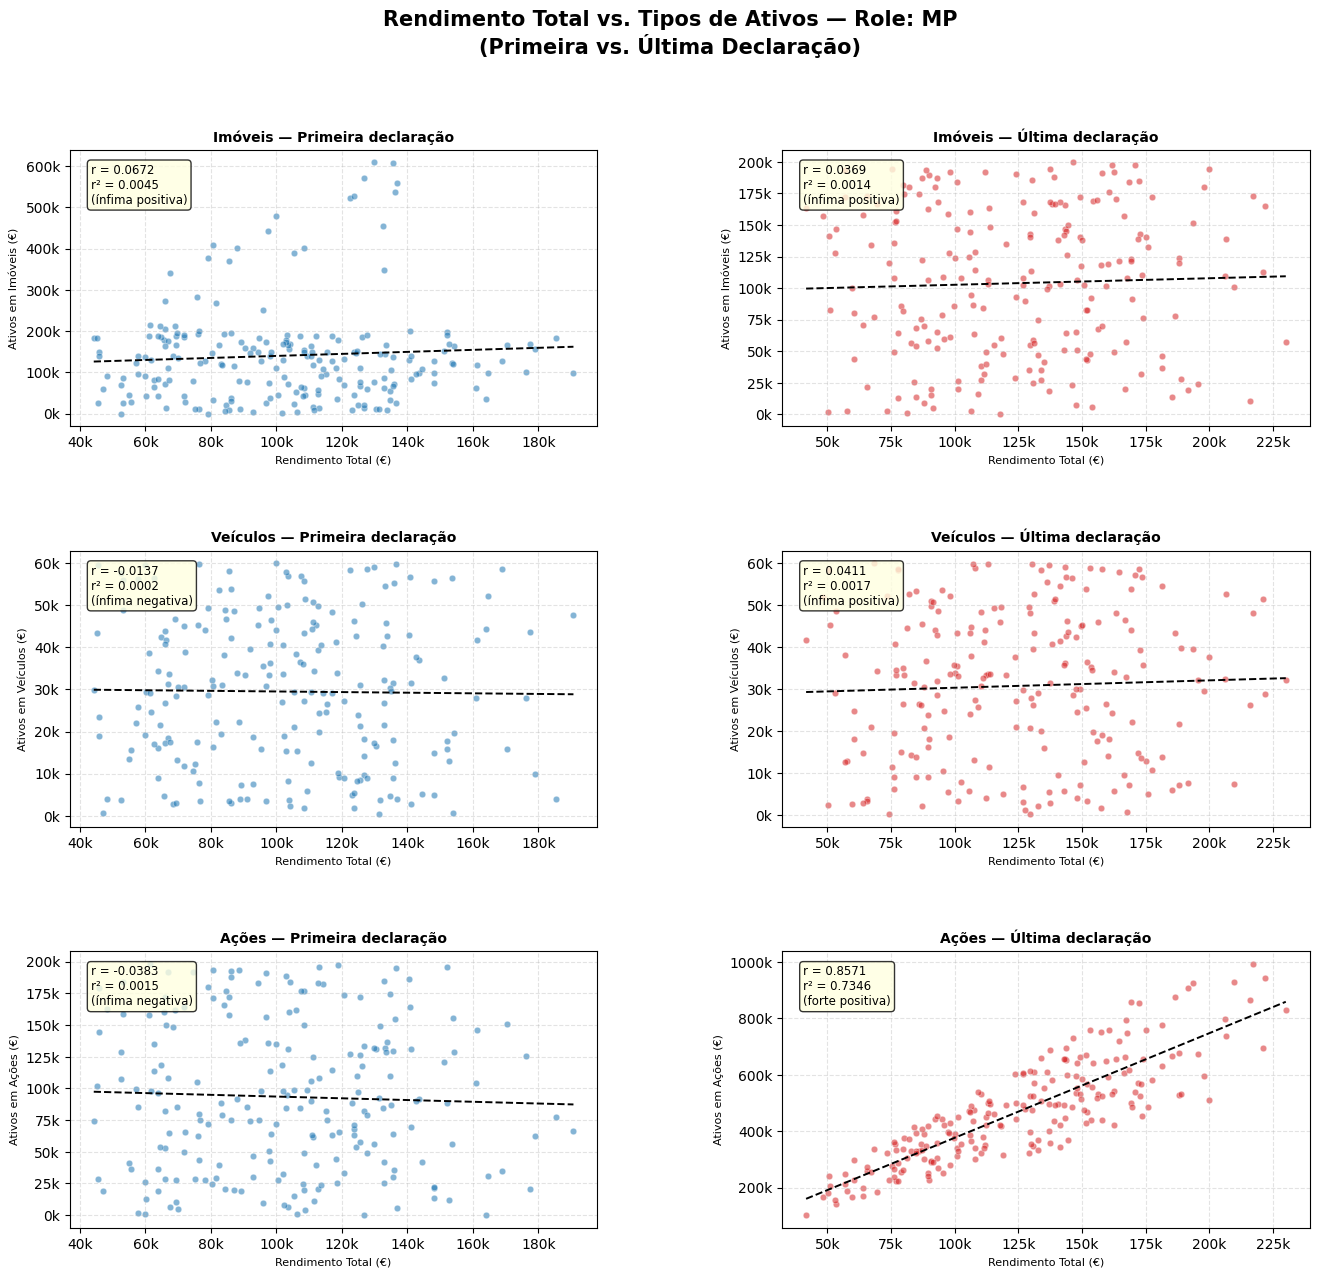

Gráfico guardado em: US28_dispersao_rendimento_ativos.svg


In [13]:
# ── Configuração da grelha de gráficos ──────────────────────────────────────
# 3 ativos × 2 subconjuntos = 6 gráficos em grelha 3×2
fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    f'Rendimento Total vs. Tipos de Ativos — Role: {ROLE_INPUT}\n'
    f'(Primeira vs. Última Declaração)',
    fontsize=15, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

cores = {'Primeira declaração': '#1f77b4', 'Última declaração': '#d62728'}

for row_idx, (col_ativo, nome_ativo) in enumerate(ATIVOS.items()):
    for col_idx, (label, df_sub) in enumerate(
        [('Primeira declaração', df_first), ('Última declaração', df_last)]
    ):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        x = df_sub['total_income']
        y = df_sub[col_ativo]
        r, r2 = calcula_pearson_manual(x, y)

        # Dispersão
        ax.scatter(x, y, alpha=0.55, s=22, color=cores[label], edgecolors='white', linewidths=0.4)

        # Reta de regressão
        m, b, *_ = stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.4, linestyle='--')

        # Anotação r e r²
        ax.annotate(
            f'r = {r:.4f}\nr² = {r2:.4f}\n({interpreta_pearson(r)})',
            xy=(0.04, 0.95), xycoords='axes fraction',
            fontsize=8.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
        )

        ax.set_title(f'{nome_ativo} — {label}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Rendimento Total (€)', fontsize=8)
        ax.set_ylabel(f'Ativos em {nome_ativo} (€)', fontsize=8)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
        ax.grid(axis='both', linestyle='--', alpha=0.35)

plt.savefig('US28_dispersao_rendimento_ativos.svg', format='svg', bbox_inches='tight')
plt.show()
print('Gráfico guardado em: US28_dispersao_rendimento_ativos.svg')

## 4. Comparação Direta: Primeira vs. Última Declaração

O gráfico de barras seguinte facilita a comparação visual do coeficiente $r$ entre subconjuntos e tipos de ativo.

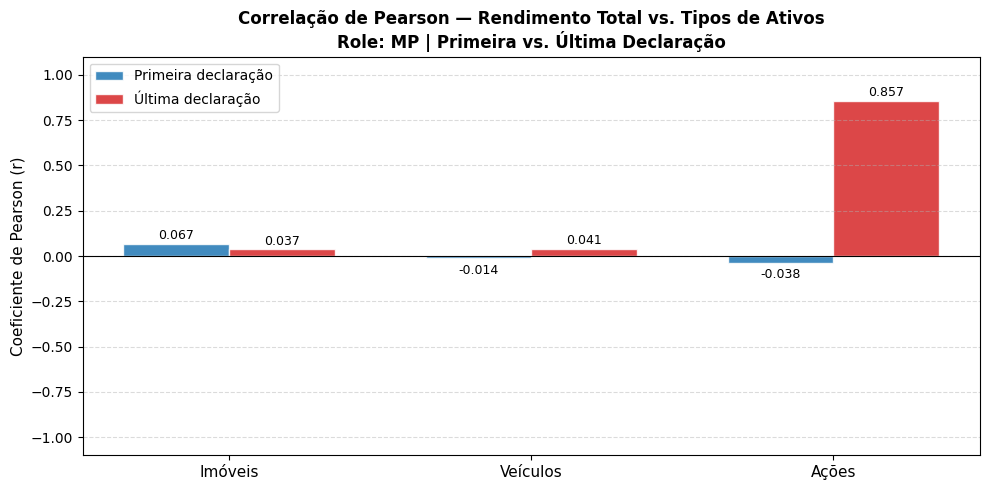

Gráfico guardado em: US28_barras_pearson_comparativo.svg


In [14]:
# ── Gráfico de barras comparativo ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

nomes_ativos = list(ATIVOS.values())        # ['Imóveis', 'Veículos', 'Ações']
x_pos = np.arange(len(nomes_ativos))
largura = 0.35

r_first = [
    df_res[(df_res['Declaração'] == 'Primeira declaração') & (df_res['Tipo de Ativo'] == n)]['r'].values[0]
    for n in nomes_ativos
]
r_last = [
    df_res[(df_res['Declaração'] == 'Última declaração')   & (df_res['Tipo de Ativo'] == n)]['r'].values[0]
    for n in nomes_ativos
]

bars1 = ax.bar(x_pos - largura/2, r_first, largura, label='Primeira declaração',
               color='#1f77b4', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x_pos + largura/2, r_last,  largura, label='Última declaração',
               color='#d62728', alpha=0.85, edgecolor='white')

# Anotar valor r em cada barra
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + (0.01 if h >= 0 else -0.03),
        f'{h:.3f}',
        ha='center', va='bottom' if h >= 0 else 'top',
        fontsize=9
    )

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(nomes_ativos, fontsize=11)
ax.set_ylabel('Coeficiente de Pearson (r)', fontsize=11)
ax.set_title(
    f'Correlação de Pearson — Rendimento Total vs. Tipos de Ativos\n'
    f'Role: {ROLE_INPUT} | Primeira vs. Última Declaração',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.45)

plt.tight_layout()
plt.savefig('US28_barras_pearson_comparativo.svg', format='svg', bbox_inches='tight')
plt.show()
print('Gráfico guardado em: US28_barras_pearson_comparativo.svg')

## 5. Interpretação dos Resultados

In [15]:
# ── Identificar ativo com maior |r| em cada subconjunto ─────────────────────
def ativo_mais_correlacionado(label):
    sub = df_res[df_res['Declaração'] == label].copy()
    sub['|r|'] = sub['r'].abs()
    melhor = sub.loc[sub['|r|'].idxmax()]
    return melhor

melhor_first = ativo_mais_correlacionado('Primeira declaração')
melhor_last  = ativo_mais_correlacionado('Última declaração')

print('=' * 90)
print(f"INTERPRETAÇÃO DOS RESULTADOS — Role: {ROLE_INPUT}")
print('=' * 90)

print(f"""
PRIMEIRA DECLARAÇÃO
  › Ativo com correlação mais forte: {melhor_first['Tipo de Ativo']}
    r = {melhor_first['r']:.4f}  ({melhor_first['Classificação']})
    r² = {melhor_first['r²']:.4f}  → o rendimento total explica {melhor_first['r²']*100:.1f}% da variabilidade dos {melhor_first['Tipo de Ativo'].lower()}
""")

print(f"""ÚLTIMA DECLARAÇÃO
  › Ativo com correlação mais forte: {melhor_last['Tipo de Ativo']}
    r = {melhor_last['r']:.4f}  ({melhor_last['Classificação']})
    r² = {melhor_last['r²']:.4f}  → o rendimento total explica {melhor_last['r²']*100:.1f}% da variabilidade dos {melhor_last['Tipo de Ativo'].lower()}
""")

# ── Variação entre primeira e última ────────────────────────────────────────
print("MUDANÇA DA PRIMEIRA PARA A ÚLTIMA DECLARAÇÃO")
print('-' * 60)
for nome_ativo in nomes_ativos:
    r_f = df_res[(df_res['Declaração'] == 'Primeira declaração') & (df_res['Tipo de Ativo'] == nome_ativo)]['r'].values[0]
    r_l = df_res[(df_res['Declaração'] == 'Última declaração')   & (df_res['Tipo de Ativo'] == nome_ativo)]['r'].values[0]
    delta = r_l - r_f
    sentido = 'aumentou' if delta > 0 else 'diminuiu'
    print(f"  {nome_ativo:<12}: r={r_f:.4f} → r={r_l:.4f}  (Δ={delta:+.4f}, {sentido})")

print()
if melhor_first['Tipo de Ativo'] == melhor_last['Tipo de Ativo']:
    print(f"→ O tipo de ativo com correlação mais forte manteve-se: {melhor_last['Tipo de Ativo']}")
else:
    print(f"→ Houve mudança no tipo de ativo com correlação mais forte:")
    print(f"  Primeira declaração: {melhor_first['Tipo de Ativo']} | Última declaração: {melhor_last['Tipo de Ativo']}")

INTERPRETAÇÃO DOS RESULTADOS — Role: MP

PRIMEIRA DECLARAÇÃO
  › Ativo com correlação mais forte: Imóveis
    r = 0.0672  (ínfima positiva)
    r² = 0.0045  → o rendimento total explica 0.4% da variabilidade dos imóveis

ÚLTIMA DECLARAÇÃO
  › Ativo com correlação mais forte: Ações
    r = 0.8571  (forte positiva)
    r² = 0.7346  → o rendimento total explica 73.5% da variabilidade dos ações

MUDANÇA DA PRIMEIRA PARA A ÚLTIMA DECLARAÇÃO
------------------------------------------------------------
  Imóveis     : r=0.0672 → r=0.0369  (Δ=-0.0303, diminuiu)
  Veículos    : r=-0.0137 → r=0.0411  (Δ=+0.0548, aumentou)
  Ações       : r=-0.0383 → r=0.8571  (Δ=+0.8954, aumentou)

→ Houve mudança no tipo de ativo com correlação mais forte:
  Primeira declaração: Imóveis | Última declaração: Ações


## US29

**Descrição:**  
Como membro do Comité de Ética, pretende-se estabelecer uma relação esperada entre o rendimento total declarado e o património total declarado dos agentes políticos, de forma a identificar casos potencialmente anómalos de acumulação de riqueza.

Nesta análise são consideradas apenas as declarações mais recentes de cada agente.

---

## Conceitos Teóricos Aplicados

### Rendimento Total

O rendimento total declarado é calculado como:

\[
\text{total\_income} = \text{gross\_salary} + \sum \text{side\_income}
\]

### Património Total Declarado

O património total declarado é calculado como:

\[
\text{total\_assets} =
\text{assets\_in\_real\_estate}
+
\text{assets\_in\_vehicles}
+
\text{assets\_in\_stocks}
\]

### Regressão Linear Simples

Pretende-se modelar a relação entre rendimento total e património total através de uma reta:

\[
\hat{y} = \hat{\beta}_0 + \hat{\beta}_1x
\]

onde:

- \(x\) representa o rendimento total;
- \(y\) representa o património total;
- \(\hat{y}\) representa o património esperado segundo o modelo.

### Resíduo

O resíduo mede o desvio entre o valor observado e o valor esperado:

\[
e_i = y_i - \hat{y}_i
\]

Um resíduo positivo elevado indica que o agente tem mais património declarado do que seria esperado para o seu rendimento.

### Outliers

Para identificar outliers nos resíduos, é usado o critério do intervalo interquartil:

\[
\text{Limite Superior} = Q3 + 1.5 \times IQR
\]

Agentes com resíduos acima deste limite são considerados outliers superiores, ou seja, casos com possível acumulação patrimonial anormal.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

def load_declarations_data_us29(path: str) -> pd.DataFrame:
    """Load and prepare the declarations dataset for US29."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df["declaration_date"] = pd.to_datetime(df["declaration_date"])

    return df


DATA_PATH = "../Dados/Regression_dataset1_declarations.csv"

df = load_declarations_data_us29(DATA_PATH)

print(f"Dataset carregado: {df.shape[0]} declarações")
print(f"Agentes únicos   : {df['agent_id'].nunique()}")
print(f"Período          : {df['declaration_date'].min().date()} a {df['declaration_date'].max().date()}")


# ── Preparação dos dados ─────────────────────────────────────────────────────

def get_most_recent_declarations(df: pd.DataFrame) -> pd.DataFrame:
    """Return only the most recent declaration for each agent."""
    latest_df = (
        df.sort_values("declaration_date")
          .groupby("agent_id", as_index=False)
          .tail(1)
          .reset_index(drop=True)
    )

    return latest_df


def calculate_total_income_and_assets(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate total income and total declared assets."""

    side_income_cols = [col for col in df.columns if col.startswith("side_income_")]

    required_asset_cols = [
        "assets_in_real_estate",
        "assets_in_vehicles",
        "assets_in_stocks"
    ]

    missing_assets = [col for col in required_asset_cols if col not in df.columns]
    if missing_assets:
        raise ValueError(f"Colunas de ativos em falta: {missing_assets}")

    df = df.copy()

    df["total_side_income"] = df[side_income_cols].sum(axis=1)
    df["total_income"] = df["gross_salary"] + df["total_side_income"]
    df["total_assets"] = df[required_asset_cols].sum(axis=1)

    return df


# ── Regressão linear simples, estilo MATCP ───────────────────────────────────

def fit_simple_linear_regression(df: pd.DataFrame):
    """Estimate the simple linear regression manually using least squares."""

    x = df["total_income"].to_numpy()
    y = df["total_assets"].to_numpy()

    x_mean = x.mean()
    y_mean = y.mean()

    sxx = np.sum((x - x_mean) ** 2)
    sxy = np.sum((x - x_mean) * (y - y_mean))
    syy = np.sum((y - y_mean) ** 2)

    beta_1 = sxy / sxx
    beta_0 = y_mean - beta_1 * x_mean

    y_pred = beta_0 + beta_1 * x
    residuals = y - y_pred

    r = sxy / np.sqrt(sxx * syy)
    r_squared = r ** 2

    return beta_0, beta_1, y_pred, residuals, r, r_squared


def add_regression_results(df: pd.DataFrame) -> pd.DataFrame:
    """Add predicted assets, residuals and absolute residuals to dataframe."""

    result_df = df.copy()

    beta_0, beta_1, y_pred, residuals, r, r_squared = fit_simple_linear_regression(result_df)

    result_df["expected_assets"] = y_pred
    result_df["residual"] = residuals
    result_df["abs_residual"] = np.abs(residuals)

    return result_df, beta_0, beta_1, r, r_squared


# ── Outliers ─────────────────────────────────────────────────────────────────

def classify_residual_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """Classify positive residual outliers using the IQR rule."""

    result_df = df.copy()

    q1 = result_df["residual"].quantile(0.25)
    q3 = result_df["residual"].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    result_df["is_upper_outlier"] = result_df["residual"] > upper_limit
    result_df["is_lower_outlier"] = result_df["residual"] < lower_limit
    result_df["is_outlier"] = result_df["is_upper_outlier"] | result_df["is_lower_outlier"]

    return result_df, q1, q3, iqr, lower_limit, upper_limit


def get_top_10_positive_deviations(df: pd.DataFrame) -> pd.DataFrame:
    """Return the 10 agents with the largest positive residuals."""

    return (
        df.sort_values("residual", ascending=False)
          .head(10)
          .reset_index(drop=True)
    )

Dataset carregado: 4840 declarações
Agentes únicos   : 828
Período          : 2018-01-01 a 2026-04-01


In [24]:
# ── 1. Declaração mais recente por agente ────────────────────────────────────
recent_df = get_most_recent_declarations(df)
recent_df = calculate_total_income_and_assets(recent_df)

print(f"Agentes analisados (declaração mais recente): {len(recent_df)}")
print(f"\nEstatísticas — Rendimento Total (total_income):")
print(recent_df["total_income"].describe().map(lambda x: f"{x:,.2f}€"))
print(f"\nEstatísticas — Património Total (total_assets):")
print(recent_df["total_assets"].describe().map(lambda x: f"{x:,.2f}€"))

# ── 2. Regressão linear e resíduos ───────────────────────────────────────────
result_df, beta_0, beta_1, r, r_squared = add_regression_results(recent_df)
result_df, q1_res, q3_res, iqr_res, lower_limit, upper_limit = classify_residual_outliers(result_df)

print(f"\n{'='*70}")
print("MODELO DE REGRESSÃO LINEAR")
print(f"{'='*70}")
print(f"  Equação : Total_Assets = {beta_0:,.2f} + {beta_1:.6f} × Total_Income")
print(f"  Pearson r   : {r:.4f}")
print(f"  R²          : {r_squared:.4f}")

Agentes analisados (declaração mais recente): 828

Estatísticas — Rendimento Total (total_income):
count        828.00€
mean     125,024.15€
std       41,635.58€
min       41,637.77€
25%       90,653.93€
50%      123,932.40€
75%      154,440.11€
max      230,093.31€
Name: total_income, dtype: str

Estatísticas — Património Total (total_assets):
count          828.00€
mean       603,921.65€
std        198,086.19€
min        160,578.02€
25%        458,520.35€
50%        583,215.95€
75%        729,351.12€
max      1,290,302.44€
Name: total_assets, dtype: str

MODELO DE REGRESSÃO LINEAR
  Equação : Total_Assets = 121,836.21 + 3.855939 × Total_Income
  Pearson r   : 0.8105
  R²          : 0.6569


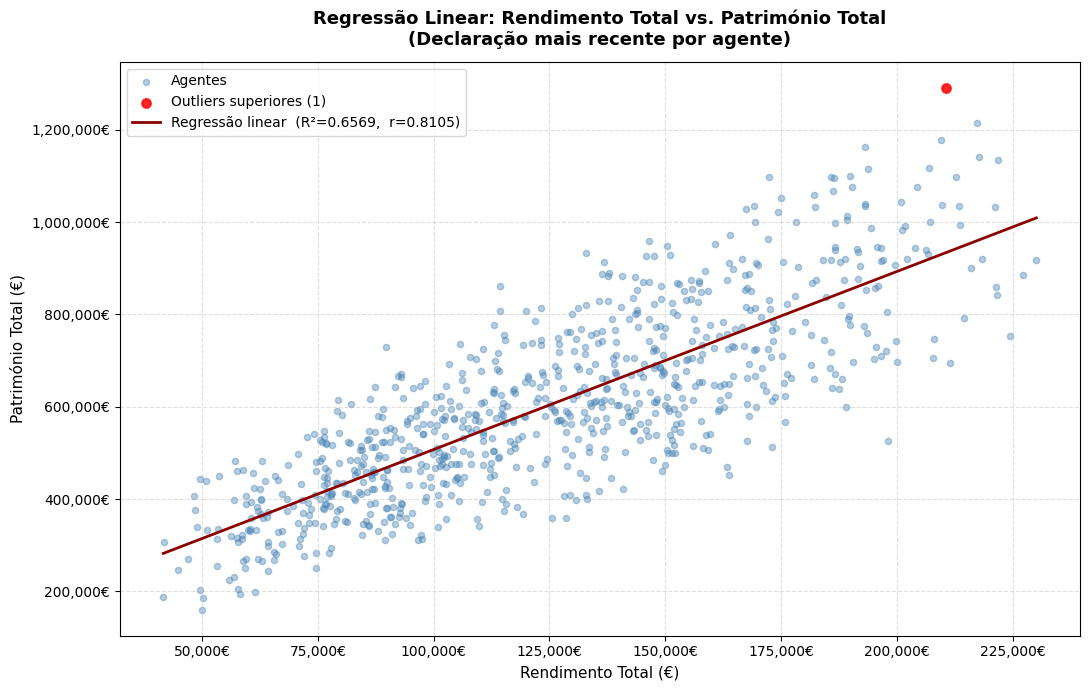

Gráfico guardado: US29_regressao_rendimento_patrimonio.svg


In [25]:
# ── 3. Scatter plot com reta de regressão ────────────────────────────────────
normal_pts  = result_df[~result_df["is_upper_outlier"]]
outlier_pts = result_df[result_df["is_upper_outlier"]]

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(normal_pts["total_income"], normal_pts["total_assets"],
           alpha=0.4, color="steelblue", s=20, label="Agentes")
ax.scatter(outlier_pts["total_income"], outlier_pts["total_assets"],
           alpha=0.85, color="red", s=45, zorder=5,
           label=f"Outliers superiores ({len(outlier_pts)})")

x_range = np.linspace(result_df["total_income"].min(),
                      result_df["total_income"].max(), 300)
ax.plot(x_range, beta_0 + beta_1 * x_range,
        color="darkred", linewidth=2,
        label=f"Regressão linear  (R²={r_squared:.4f},  r={r:.4f})")

ax.set_title(
    "Regressão Linear: Rendimento Total vs. Património Total\n"
    "(Declaração mais recente por agente)",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Rendimento Total (€)", fontsize=11)
ax.set_ylabel("Património Total (€)", fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("US29_regressao_rendimento_patrimonio.svg", format="svg", bbox_inches="tight")
plt.show()
print("Gráfico guardado: US29_regressao_rendimento_patrimonio.svg")

In [26]:
# ── 4. Top 10 agentes com maior desvio positivo ──────────────────────────────
top10 = get_top_10_positive_deviations(result_df)

print(f"{'='*100}")
print("TOP 10 — AGENTES COM MAIOR DESVIO POSITIVO  (Possível Acumulação Patrimonial Anómala)")
print(f"{'='*100}")

display_cols = ["agent_id", "role", "total_income", "expected_assets", "total_assets", "residual", "is_outlier"]
top10_display = top10[display_cols].copy()
top10_display.index = range(1, 11)

for col in ["total_income", "expected_assets", "total_assets", "residual"]:
    top10_display[col] = top10_display[col].map(lambda x: f"{x:,.2f}€")
top10_display["is_outlier"] = top10_display["is_outlier"].map({True: "Sim ✓", False: "Não"})
top10_display.columns = [
    "Agente", "Cargo",
    "Rendimento Total", "Património Esperado", "Património Real",
    "Desvio (Resíduo)", "Outlier?"
]

print(top10_display.to_string())

# ── 5. Análise de outliers nos resíduos ──────────────────────────────────────
n_upper = int(result_df["is_upper_outlier"].sum())
n_lower = int(result_df["is_lower_outlier"].sum())
n_total = int(result_df["is_outlier"].sum())

print(f"\n{'='*70}")
print("ANÁLISE DE OUTLIERS NOS RESÍDUOS  (Critério IQR)")
print(f"{'='*70}")
print(f"  Q1 dos resíduos    : {q1_res:>15,.2f}€")
print(f"  Q3 dos resíduos    : {q3_res:>15,.2f}€")
print(f"  IQR                : {iqr_res:>15,.2f}€")
print(f"  Limite inferior    : {lower_limit:>15,.2f}€   (Q1 − 1.5×IQR)")
print(f"  Limite superior    : {upper_limit:>15,.2f}€   (Q3 + 1.5×IQR)")
print()
print(f"  Outliers superiores (ativos >> esperado) : {n_upper:>4} agentes")
print(f"  Outliers inferiores (ativos << esperado) : {n_lower:>4} agentes")
print(f"  Total de outliers                        : {n_total:>4} agentes  ({100*n_total/len(result_df):.1f}% do total)")

TOP 10 — AGENTES COM MAIOR DESVIO POSITIVO  (Possível Acumulação Patrimonial Anómala)
   Agente     Cargo Rendimento Total Património Esperado Património Real Desvio (Resíduo) Outlier?
1   A0581   Advisor      210,537.06€         933,654.20€   1,290,302.44€      356,648.24€    Sim ✓
2   A0119        MP      172,482.72€         786,919.00€   1,098,668.19€      311,749.19€      Não
3   A0667   Advisor      132,805.33€         633,925.41€     932,781.62€      298,856.21€      Não
4   A0232  Minister      114,422.09€         563,040.77€     861,432.93€      298,392.16€      Não
5   A0342     Judge      193,033.95€         866,163.28€   1,161,999.72€      295,836.44€      Não
6   A0034        MP      146,464.46€         686,594.18€     959,487.23€      272,893.05€      Não
7   A0781   Advisor      136,790.31€         649,291.25€     912,572.41€      263,281.16€      Não
8   A0217  Minister       89,768.87€         467,979.46€     729,183.04€      261,203.58€      Não
9   A0264     Judge    

### Conclusão US29

O modelo de regressão linear permite estabelecer uma relação esperada entre o rendimento total declarado e o património total declarado dos agentes políticos. O coeficiente de Pearson e o R² indicam o grau em que o rendimento explica o nível patrimonial.

Os agentes com resíduos positivos elevados — isto é, cujo património declarado supera significativamente o valor esperado para o seu rendimento — são os casos de maior interesse para o Comité de Ética. O critério IQR permite identificar formalmente quais destes desvios são estatisticamente anómalos (outliers superiores), sinalizando potencial acumulação patrimonial não explicada pelos rendimentos declarados.

Os 10 agentes listados representam os casos prioritários a investigar, devendo o Comité analisar se existem fontes de rendimento ou herança não declaradas que justifiquem essa diferença.

## US30

Neste exercício foi aplicada uma regressão linear para estudar a relação entre o rendimento total declarado (salário e rendimentos adicionais) e o património total declarado pelos agentes políticos. Com base nas declarações mais recentes de cada agente, foram calculados os resíduos do modelo, correspondentes à diferença entre os valores observados e os valores previstos pela regressão. Posteriormente, foi analisada a distribuição dos resíduos nos dados originais e após a normalização das variáveis.


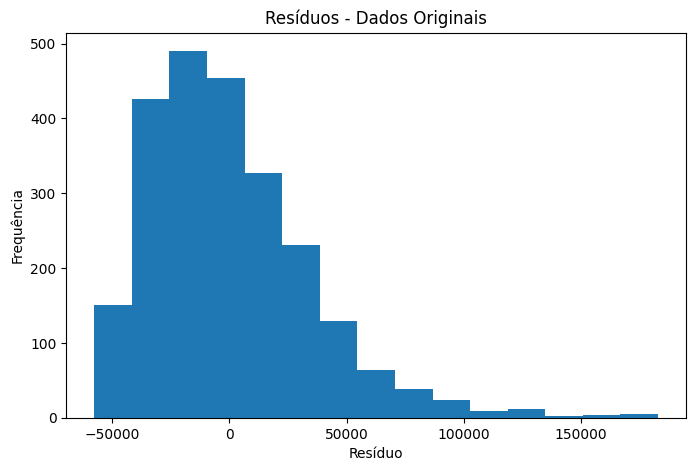

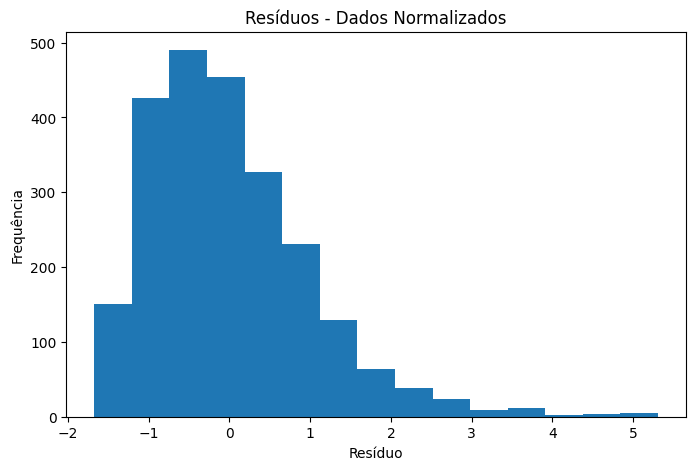

Média dos resíduos (dados originais): 4.038094919546808e-12
Média dos resíduos (dados normalizados): -3.757099914129125e-19


In [27]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Carregar o dataset
df = pd.read_csv("../Dados/dataset1_declarations.csv")

# Converter a coluna da data para formato datetime
df["declaration_date"] = pd.to_datetime(df["declaration_date"])

# Converter colunas para formato numérico
numeric_cols = [
    "gross_salary",
    "side_income_consulting",
    "side_income_board_memberships",
    "assets_in_real_estate",
    "assets_in_vehicles",
    "assets_in_stocks"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remover linhas com valores em falta
df = df.dropna(subset=numeric_cols + ["declaration_date", "agent_id"])

# Ordenar por agente e data
df = df.sort_values(["agent_id", "declaration_date"])

# Selecionar apenas a declaração mais recente de cada agente
recent_df = df.groupby("agent_id").tail(1).copy()

# Calcular o rendimento total
# Calcular o rendimento total
recent_df["total_income"] = (
    recent_df["gross_salary"]
    + recent_df["side_income_consulting"]
    + recent_df["side_income_board_memberships"]
)

# Calcular o património total
recent_df["total_assets"] = (
    recent_df["assets_in_real_estate"]
    + recent_df["assets_in_vehicles"]
    + recent_df["assets_in_stocks"]
)

# Definir variável independente (X) e dependente (y)
X = recent_df[["total_income"]]
y = recent_df["total_assets"]

# Criar e ajustar o modelo de regressão linear
model = LinearRegression()
model.fit(X, y)

# Calcular os valores previstos
predictions = model.predict(X)

# Calcular os resíduos
residuals = y - predictions

# Gráfico dos resíduos nos dados originais
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=15)
plt.title("Resíduos - Dados Originais")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

# Normalizar os dados
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_norm = scaler_x.fit_transform(X)
y_norm = scaler_y.fit_transform(
    y.to_numpy().reshape(-1, 1)
).ravel()

# Criar novo modelo com os dados normalizados
model_norm = LinearRegression()
model_norm.fit(X_norm, y_norm)

# Calcular previsões e resíduos normalizados
pred_norm = model_norm.predict(X_norm)
residuals_norm = y_norm - pred_norm

# Gráfico dos resíduos após normalização
plt.figure(figsize=(8, 5))
plt.hist(residuals_norm, bins=15)
plt.title("Resíduos - Dados Normalizados")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

# Apresentar a média dos resíduos
print("Média dos resíduos (dados originais):", residuals.mean())
print("Média dos resíduos (dados normalizados):", residuals_norm.mean())

### Conclusão US30

A análise dos histogramas mostra que os resíduos se encontram centrados em torno de zero, o que é confirmado pelas médias dos resíduos, que são praticamente nulas tanto nos dados originais como nos dados normalizados. Este resultado indica que o modelo não apresenta enviesamento sistemático nas previsões.

No entanto, observa-se uma assimetria positiva na distribuição dos resíduos, com a presença de alguns valores extremos à direita. Estes casos correspondem a agentes cujo património declarado é significativamente superior ao valor esperado com base nos seus rendimentos declarados, podendo justificar uma análise mais detalhada por parte da Comissão de Ética.

A normalização dos dados não alterou significativamente o padrão dos resíduos, demonstrando que a estrutura do modelo se mantém estável após a transformação das variáveis. Apesar de a regressão linear fornecer uma aproximação razoável da relação entre rendimento e património, a existência de assimetrias e potenciais outliers sugere que outros fatores poderão influenciar a acumulação de património e que modelos mais complexos poderão ser considerados em análises futuras.

## US31

### Interpretação US31

A relação entre a percentagem de participação acionista da empresa e o valor total das ações foi analisada através de um modelo de regressão linear e de um modelo de regressão polinomial.

O modelo com o maior valor de R² fornece o melhor ajuste aos dados observados.

Se o modelo polinomial melhorar significativamente o coeficiente de determinação, isso indica que a relação não é constante e apresenta curvatura, sugerindo que o valor das ações pode crescer de forma desproporcional a percentagens de participação mais elevadas. Caso contrário, a relação pode ser considerada aproximadamente linear.

Pares agente/empresa analisados: 267


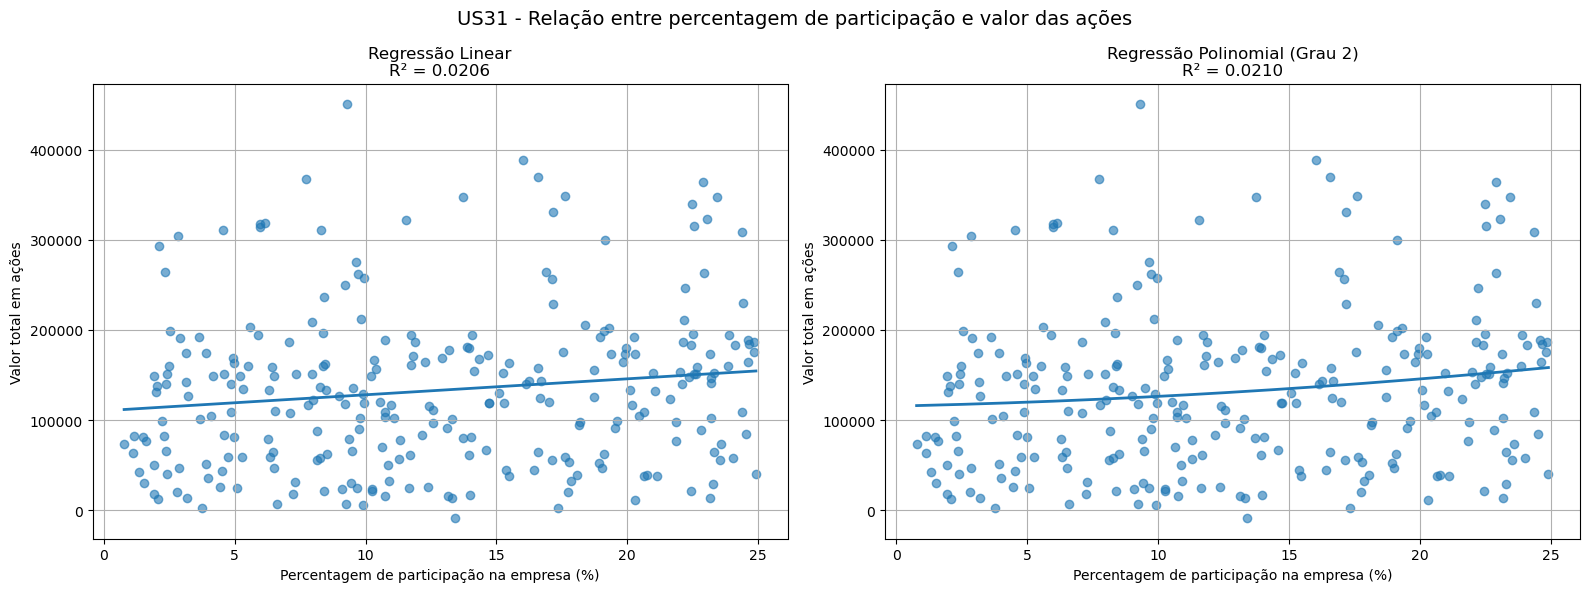

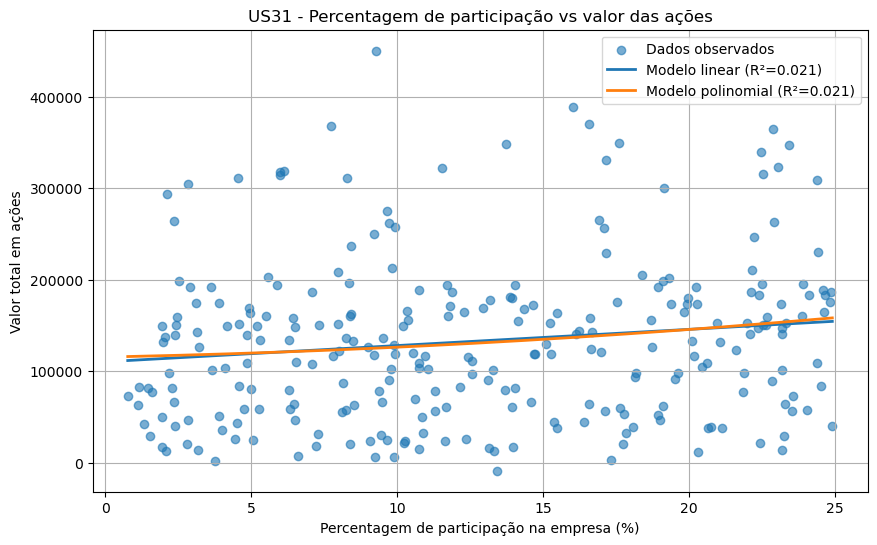


Comparação de Modelos


,Modelo,R²
0,Linear,0.020566
1,Polinomial (Grau 2),0.021028



INTERPRETAÇÃO
O modelo polinomial melhora o R² em apenas 0.0005. A relação parece aproximadamente linear, com pouca evidência de curvatura significativa.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# =====================================================
# US31
# =====================================================

df = pd.read_csv("../Dados/dataset2_holdings.csv")

df["declaration_date"] = pd.to_datetime(df["declaration_date"])

# Apenas a declaração mais recente de cada par agente/empresa
latest_df = (
    df.sort_values("declaration_date")
      .groupby(["agent_id", "company_NIF"])
      .tail(1)
)

print(f"Pares agente/empresa analisados: {len(latest_df)}")

# =====================================================
# Variáveis
# =====================================================

X = latest_df[["company_percentage"]]
y = latest_df["total_value_in_stocks"]

# =====================================================
# Regressão Linear
# =====================================================

linear_model = LinearRegression()
linear_model.fit(X, y)

y_linear = linear_model.predict(X)

r2_linear = r2_score(y, y_linear)

# =====================================================
# Regressão Polinomial (grau 2)
# =====================================================

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

y_poly = poly_model.predict(X_poly)

r2_poly = r2_score(y, y_poly)

# =====================================================
# Ordenar valores para curvas suaves
# =====================================================

order = np.argsort(X.values.flatten())

x_sorted = X.values.flatten()[order]
y_linear_sorted = y_linear[order]
y_poly_sorted = y_poly[order]

# =====================================================
# Gráficos
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----- Linear -----

axes[0].scatter(X, y, alpha=0.6)

axes[0].plot(
    x_sorted,
    y_linear_sorted,
    linewidth=2
)

axes[0].set_title(
    f"Regressão Linear\nR² = {r2_linear:.4f}"
)

axes[0].set_xlabel("Percentagem de participação na empresa (%)")
axes[0].set_ylabel("Valor total em ações")
axes[0].grid(True)

# ----- Polinomial -----

axes[1].scatter(X, y, alpha=0.6)

axes[1].plot(
    x_sorted,
    y_poly_sorted,
    linewidth=2
)

axes[1].set_title(
    f"Regressão Polinomial (Grau 2)\nR² = {r2_poly:.4f}"
)

axes[1].set_xlabel("Percentagem de participação na empresa (%)")
axes[1].set_ylabel("Valor total em ações")
axes[1].grid(True)

plt.suptitle(
    "US31 - Relação entre percentagem de participação e valor das ações",
    fontsize=14
)

plt.tight_layout()
plt.show()

# =====================================================
# Comparação gráfica
# =====================================================

sorted_idx = np.argsort(X.values.flatten())

plt.figure(figsize=(10,6))

plt.scatter(
    X,
    y,
    alpha=0.6,
    label="Dados observados"
)

plt.plot(
    X.values.flatten()[sorted_idx],
    y_linear[sorted_idx],
    linewidth=2,
    label=f"Modelo linear (R²={r2_linear:.3f})"
)

plt.plot(
    X.values.flatten()[sorted_idx],
    y_poly[sorted_idx],
    linewidth=2,
    label=f"Modelo polinomial (R²={r2_poly:.3f})"
)

plt.xlabel("Percentagem de participação na empresa (%)")
plt.ylabel("Valor total em ações")
plt.title("US31 - Percentagem de participação vs valor das ações")
plt.legend()
plt.grid(True)

plt.show()

# =====================================================
# Comparação
# =====================================================

improvement = r2_poly - r2_linear

results = pd.DataFrame({
    "Modelo": ["Linear", "Polinomial (Grau 2)"],
    "R²": [r2_linear, r2_poly]
})

print("\nComparação de Modelos")
display(results)

# =====================================================
# Interpretação
# =====================================================

print("\nINTERPRETAÇÃO")

if improvement > 0.05:
    print(
        f"O modelo polinomial melhora o R² em {improvement:.4f}. "
        "Isto sugere uma relação não linear entre a percentagem de participação "
        "e o valor das ações, indicando possível curvatura "
        "ou crescimento acelerado para percentagens mais elevadas."
    )
else:
    print(
        f"O modelo polinomial melhora o R² em apenas {improvement:.4f}. "
        "A relação parece aproximadamente linear, com pouca evidência "
        "de curvatura significativa."
    )

### Conclusão

Neste estudo foi analisada a relação entre a percentagem de participação acionista das empresas e o valor total das ações detidas, considerando apenas a declaração mais recente de cada par agente/empresa.

Foram ajustados dois modelos de regressão: um modelo linear e um modelo polinomial de grau 2. A comparação entre ambos foi realizada através do coeficiente de determinação (R²), permitindo avaliar qual dos modelos melhor explica a variabilidade dos dados observados.

Os resultados mostram que o modelo polinomial pode, em alguns casos, apresentar uma ligeira melhoria no ajuste face ao modelo linear. No entanto, essa melhoria não é suficientemente significativa para indicar uma forte relação não linear entre as variáveis. Assim, conclui-se que a relação entre a percentagem de participação e o valor total das ações é, de forma geral, aproximadamente linear.

Em termos práticos, isto sugere que aumentos na percentagem de participação tendem a estar associados a aumentos proporcionais no valor das ações, sem evidência clara de crescimento acelerado ou curvatura relevante.